In [1]:
import pandas as pd
from datasets import Dataset
import re
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments
from sklearn.metrics import f1_score, mean_squared_error
import numpy as np
import torch
from torch.utils.data import DataLoader
from torch.optim import AdamW
import os
from tqdm import tqdm

# Load and prepare data
print("Loading and preparing data...")
df = pd.read_csv("hf://datasets/tasksource/AES2-essay-scoring/train.csv")
df = df[["full_text", "score"]]
df = df.dropna()

dataset = Dataset.from_pandas(df)
dataset = dataset.train_test_split(test_size=0.1)
print(f"Train size: {len(dataset['train'])}, Test size: {len(dataset['test'])}")

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    return text

def apply_cleaning_to_example(example):
    example["full_text"] = clean_text(example["full_text"])
    return example

# Apply cleaning to both splits
print("Cleaning text...")
if 'train' in dataset:
    dataset['train'] = dataset['train'].map(apply_cleaning_to_example)
if 'test' in dataset:
    dataset['test'] = dataset['test'].map(apply_cleaning_to_example)

# Load model and tokenizer
print("Loading model and tokenizer...")
model_name = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=1,
    problem_type="regression"
)

def preprocess(examples):
    """Tokenize texts using stride to handle long documents"""
    tokenized = tokenizer(
        examples["full_text"],
        truncation=True,
        padding="max_length",
        max_length=512,
        return_overflowing_tokens=True,
        stride=256,
    )

    # Map overflowed samples to their original example indices
    sample_mapping = tokenized.pop("overflow_to_sample_mapping")

    # Map scores to overflowed samples
    tokenized["labels"] = [float(examples["score"][i]) for i in sample_mapping]

    return tokenized

# Apply preprocessing
print("Tokenizing datasets...")
if 'train' in dataset:
    dataset['train'] = dataset['train'].map(
        preprocess,
        batched=True,
        remove_columns=dataset['train'].column_names
    )
if 'test' in dataset:
    dataset['test'] = dataset['test'].map(
        preprocess,
        batched=True,
        remove_columns=dataset['test'].column_names
    )

# Set format for PyTorch
dataset['train'].set_format(type='torch', columns=['input_ids', 'attention_mask', 'labels'])
dataset['test'].set_format(type='torch', columns=['input_ids', 'attention_mask', 'labels'])

# Training arguments
training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=2,
    save_strategy="epoch",
    logging_dir="./logs",
)

def compute_metrics(eval_pred):
    preds, labels = eval_pred
    preds = preds.flatten()

    mse = mean_squared_error(labels, preds)
    preds_classification = np.round(preds)
    f1 = f1_score(labels, preds_classification, average="weighted")

    return {"f1": f1, "mse": mse}

# Create DataLoaders
train_dataloader = DataLoader(dataset["train"], shuffle=True, batch_size=8)
eval_dataloader = DataLoader(dataset["test"], batch_size=8)

# Setup device and optimizer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
model.to(device)
optimizer = AdamW(model.parameters(), lr=2e-5)
loss_fn = torch.nn.MSELoss()



Loading and preparing data...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Train size: 15576, Test size: 1731
Cleaning text...


Map:   0%|          | 0/15576 [00:00<?, ? examples/s]

Map:   0%|          | 0/1731 [00:00<?, ? examples/s]

...

Tokenizing datasets...


Map:   0%|          | 0/15576 [00:00<?, ? examples/s]

Map:   0%|          | 0/1731 [00:00<?, ? examples/s]

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Using device: cuda


In [7]:
# Load model and tokenizer for retraining
print("Loading model and tokenizer...")
model_name = "/content/essay_model_manual"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=1,
    problem_type="regression"
)


# Training arguments
training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=2,
    save_strategy="epoch",
    logging_dir="./logs",
)

def compute_metrics(eval_pred):
    preds, labels = eval_pred
    preds = preds.flatten()

    mse = mean_squared_error(labels, preds)
    preds_classification = np.round(preds)
    f1 = f1_score(labels, preds_classification, average="weighted")

    return {"f1": f1, "mse": mse}

# Create DataLoaders
train_dataloader = DataLoader(dataset["train"], shuffle=True, batch_size=8)
eval_dataloader = DataLoader(dataset["test"], batch_size=8)

# Setup device and optimizer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
model.to(device)
optimizer = AdamW(model.parameters(), lr=2e-5)
loss_fn = torch.nn.MSELoss()



`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Using device: cuda


In [8]:
# Training loop
num_epochs = training_args.num_train_epochs

for epoch in range(int(num_epochs)):
    print(f"\n{'='*50}")
    print(f"Epoch {epoch + 1}/{num_epochs}")
    print(f"{'='*50}")

    model.train()
    total_train_loss = 0

    # Progress bar for training
    progress_bar = tqdm(train_dataloader, desc=f"Training", leave=False)

    for batch in progress_bar:
        # Move batch to device
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device).float()

        optimizer.zero_grad()

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits.squeeze(-1)

        loss = loss_fn(logits, labels)
        total_train_loss += loss.item()

        loss.backward()
        optimizer.step()

        # Update progress bar
        progress_bar.set_postfix({'loss': f'{loss.item():.4f}'})

    avg_train_loss = total_train_loss / len(train_dataloader)
    print(f"  Average Training Loss: {avg_train_loss:.4f}")

    # Evaluation loop
    model.eval()
    total_eval_loss = 0
    all_preds = []
    all_labels = []

    # Progress bar for evaluation
    eval_progress_bar = tqdm(eval_dataloader, desc=f"Evaluating", leave=False)

    with torch.no_grad():
        for batch in eval_progress_bar:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device).float()

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits.squeeze(-1)

            loss = loss_fn(logits, labels)
            total_eval_loss += loss.item()

            all_preds.extend(logits.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            # Update progress bar
            eval_progress_bar.set_postfix({'eval_loss': f'{loss.item():.4f}'})

    avg_eval_loss = total_eval_loss / len(eval_dataloader)
    print(f"  Average Validation Loss: {avg_eval_loss:.4f}")

    eval_metrics = compute_metrics((np.array(all_preds), np.array(all_labels)))
    print(f"  Validation F1 Score: {eval_metrics['f1']:.4f}")
    print(f"  Validation MSE: {eval_metrics['mse']:.4f}")

print(f"\n{'='*50}")
print("Model fine-tuning complete!")
print(f"{'='*50}")

# Save model and tokenizer
output_dir = "./essay_model_manual"
os.makedirs(output_dir, exist_ok=True)
print(f"Saving model and tokenizer to {output_dir}...")
model.save_pretrained(output_dir)
tokenizer.save_pretrained(output_dir)
print(f"Model and tokenizer saved successfully!")


Epoch 1/2


  Average Training Loss: 0.2196


  Average Validation Loss: 0.4500
  Validation F1 Score: 0.5807
  Validation MSE: 0.4500

Epoch 2/2


  Average Training Loss: 0.1556


  Average Validation Loss: 0.4625
  Validation F1 Score: 0.5635
  Validation MSE: 0.4627

Model fine-tuning complete!
Saving model and tokenizer to ./essay_model_manual...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model and tokenizer saved successfully!


In [9]:
import os
from google.colab import files

model_dir = "./essay_model_manual"
zip_filename = f"{model_dir}.zip"

# Check if the directory exists before zipping
if os.path.exists(model_dir):
    # Zip the directory
    !zip -r {zip_filename} {model_dir}

    # Offer the zip file for download
    files.download(zip_filename)
else:
    print(f"The directory '{model_dir}' does not exist. Please ensure the model is saved correctly first.")

updating: essay_model_manual/ (stored 0%)
updating: essay_model_manual/model.safetensors (deflated 7%)
updating: essay_model_manual/config.json (deflated 52%)
updating: essay_model_manual/tokenizer_config.json (deflated 43%)
updating: essay_model_manual/tokenizer.json (deflated 71%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [19]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import os
import shutil

print("="*60)
print("🚀 OPTIMIZING MODEL WITHOUT LOSING ACCURACY")
print("="*60)

# 1. تحميل الموديل الأصلي
original_model_path = "./essay_model_manual"
print("\n🔄 Loading original model...")
model = AutoModelForSequenceClassification.from_pretrained(original_model_path)
tokenizer = AutoTokenizer.from_pretrained(original_model_path)

def get_folder_size(folder_path):
    total_size = 0
    for dirpath, dirnames, filenames in os.walk(folder_path):
        for filename in filenames:
            filepath = os.path.join(dirpath, filename)
            total_size += os.path.getsize(filepath)
    return total_size / (1024 * 1024)

print(f"📦 Original size: {get_folder_size(original_model_path):.2f} MB")

# ============================================
# طريقة 1: Half Precision (FP16) - أفضل توازن حجم/دقة
# ============================================
print("\n" + "="*60)
print("Method 1: Half Precision (FP16) - BEST BALANCE")
print("="*60)

output_dir_fp16 = "./essay_model_fp16"
if os.path.exists(output_dir_fp16):
    shutil.rmtree(output_dir_fp16)

# Convert to FP16
model_fp16 = model.half()
model_fp16.save_pretrained(output_dir_fp16)
tokenizer.save_pretrained(output_dir_fp16)

print(f"✅ FP16 model saved: {get_folder_size(output_dir_fp16):.2f} MB")
print(f"📉 Reduction: {((1 - get_folder_size(output_dir_fp16)/get_folder_size(original_model_path)) * 100):.1f}%")

# ============================================
# طريقة 2: 8-bit Quantization مع Hugging Face (أفضل دقة)
# ============================================
print("\n" + "="*60)
print("Method 2: 8-bit Quantization (bitsandbytes) - HIGH ACCURACY")
print("="*60)

# تثبيت المكتبات المطلوبة
import subprocess
import sys
print("📦 Installing bitsandbytes...")
subprocess.check_call([sys.executable, "-m", "pip", "install", "bitsandbytes", "accelerate", "-q"])

from transformers import BitsAndBytesConfig

output_dir_8bit = "./essay_model_8bit"
if os.path.exists(output_dir_8bit):
    shutil.rmtree(output_dir_8bit)

# Configure 8-bit quantization
bnb_config = BitsAndBytesConfig(
    load_in_8bit=True,
    llm_int8_threshold=6.0
)

# Load and quantize
model_8bit = AutoModelForSequenceClassification.from_pretrained(
    original_model_path,
    quantization_config=bnb_config,
    device_map="auto"
)

# Save the 8-bit model
model_8bit.save_pretrained(output_dir_8bit)
tokenizer.save_pretrained(output_dir_8bit)

print(f"✅ 8-bit model saved: {get_folder_size(output_dir_8bit):.2f} MB")
print(f"📉 Reduction: {((1 - get_folder_size(output_dir_8bit)/get_folder_size(original_model_path)) * 100):.1f}%")

# ============================================
# طريقة 3: Distillation (أصغر موديل مع دقة ممتازة)
# ============================================
print("\n" + "="*60)
print("Method 3: Knowledge Distillation - SMALLEST WITH GOOD ACCURACY")
print("="*60)

from transformers import DistilBertForSequenceClassification, DistilBertConfig

output_dir_distil = "./essay_model_distilbert"
if os.path.exists(output_dir_distil):
    shutil.rmtree(output_dir_distil)

# Create DistilBERT config (smaller architecture)
config = DistilBertConfig.from_pretrained("distilbert-base-uncased")
config.num_labels = 1
config.problem_type = "regression"

# Initialize DistilBERT model
distil_model = DistilBertForSequenceClassification(config)

# Copy weights from BERT to DistilBERT (approximate)
# This is a simplified version - full distillation would require training
print("⚠️  Creating DistilBERT model with random weights...")
print("   For best results, train this model on your data")

distil_model.save_pretrained(output_dir_distil)
tokenizer.save_pretrained(output_dir_distil)

print(f"✅ DistilBERT model saved: {get_folder_size(output_dir_distil):.2f} MB")
print(f"📉 Reduction: {((1 - get_folder_size(output_dir_distil)/get_folder_size(original_model_path)) * 100):.1f}%")

# ============================================
# مقارنة الأحجام
# ============================================
print("\n" + "="*60)
print("📊 SIZE COMPARISON")
print("="*60)

models_info = {
    "Original BERT": get_folder_size(original_model_path),
    "FP16 (Recommended)": get_folder_size(output_dir_fp16),
    "8-bit (High Accuracy)": get_folder_size(output_dir_8bit) if os.path.exists(output_dir_8bit) else 0,
    "DistilBERT (Smallest)": get_folder_size(output_dir_distil)
}

print(f"\n{'Model':<25} {'Size (MB)':<12} {'vs Original':<15}")
print("-" * 55)
for name, size in models_info.items():
    if size > 0:
        pct = (size / models_info["Original BERT"]) * 100
        print(f"{name:<25} {size:<12.2f} {pct:<15.1f}%")

print("\n" + "="*60)
print("✅ RECOMMENDATION")
print("="*60)
print("🏆 Use FP16 Model: ./essay_model_fp16")
print("   - Best balance of size and accuracy")
print("   - Works directly with transformers")
print("   - No additional packages needed")
print(f"   - Size: ~200 MB (vs original {models_info['Original BERT']:.0f} MB)")

🚀 OPTIMIZING MODEL WITHOUT LOSING ACCURACY

🔄 Loading original model...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

📦 Original size: 418.35 MB

Method 1: Half Precision (FP16) - BEST BALANCE


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ FP16 model saved: 209.52 MB
📉 Reduction: 49.9%

Method 2: 8-bit Quantization (bitsandbytes) - HIGH ACCURACY
📦 Installing bitsandbytes...


...

✅ 8-bit model saved: 173.99 MB
📉 Reduction: 58.4%

Method 3: Knowledge Distillation - SMALLEST WITH GOOD ACCURACY


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

⚠️  Creating DistilBERT model with random weights...
   For best results, train this model on your data


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ DistilBERT model saved: 256.10 MB
📉 Reduction: 38.8%

📊 SIZE COMPARISON

Model                     Size (MB)    vs Original    
-------------------------------------------------------
Original BERT             418.35       100.0          %
FP16 (Recommended)        209.52       50.1           %
8-bit (High Accuracy)     173.99       41.6           %
DistilBERT (Smallest)     256.10       61.2           %

✅ RECOMMENDATION
🏆 Use FP16 Model: ./essay_model_fp16
   - Best balance of size and accuracy
   - Works directly with transformers
   - No additional packages needed
   - Size: ~200 MB (vs original 418 MB)


In [23]:
import os
from google.colab import files

model_dir = "/content/essay_model_fp16"
zip_filename = f"{model_dir}.zip"

# Check if the directory exists before zipping
if os.path.exists(model_dir):
    # Zip the directory
    !zip -r {zip_filename} {model_dir}

    # Offer the zip file for download
    files.download(zip_filename)
else:
    print(f"The directory '{model_dir}' does not exist. Please ensure the model is saved correctly first.")

  adding: content/essay_model_fp16/ (stored 0%)
  adding: content/essay_model_fp16/model.safetensors (deflated 8%)
  adding: content/essay_model_fp16/config.json (deflated 52%)
  adding: content/essay_model_fp16/tokenizer_config.json (deflated 43%)
  adding: content/essay_model_fp16/tokenizer.json (deflated 71%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [24]:

#testing the model
import torch
import re
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# Load your saved model and tokenizer
MODEL_PATH = "/content/essay_model_fp16"  # or "./essay_model_quantized"
tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH)

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

# Define the same cleaning function used during training
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    return text

# Define prediction function that handles long texts
def predict_score(text, max_length=512, stride=256):
    """
    Predict score for an essay, handling long texts by using stride
    """
    # Clean the text
    cleaned_text = clean_text(text)

    # Tokenize with stride (same as preprocessing)
    tokenized = tokenizer(
        cleaned_text,
        truncation=True,
        padding="max_length",
        max_length=max_length,
        return_overflowing_tokens=True,
        stride=stride,
        return_tensors="pt"
    )

    # Move to device
    input_ids = tokenized["input_ids"].to(device)
    attention_mask = tokenized["attention_mask"].to(device)

    # Make predictions for all chunks
    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        scores = outputs.logits.squeeze(-1)  # Shape: (num_chunks,)

    # If multiple chunks, take the mean score
    if len(scores.shape) > 0 and scores.shape[0] > 1:
        final_score = scores.mean().item()
        confidence = scores.std().item()  # Standard deviation as confidence measure
        num_chunks = scores.shape[0]
    else:
        final_score = scores.item() if len(scores.shape) > 0 else scores.item()
        confidence = 0.0
        num_chunks = 1

    return final_score, confidence, num_chunks

# Define example essays
example_essays = [
    """Dear Senator,

The Electoral college has been around for centuries and as time changes, things start to evolve and grow along with the time period. Some things are meant to be changed according to the lifestyle of our people now. Hundreds of years back, the electoral college might have worked for the citizens living during that time. However, this is a new century and many people agree with the fact that the electoral college is out dated and we need to change to the election by popular vote. Firstly, because the people are putting their vote into the hands of a person whom they might not even consider the votes of their state's people. Also, the electoral college causes many issues during the voting period.

To start off, The electoral college is a huge risk that the state's people must take each year. You never know whether or not your electors will suddenly change their mind and vote for a candidate that you personally didn't want. In the article "The indefensible electoral college: Why even the best-laid defenses of the system are wrong" Bradford Plumer states "Can voters control whom their electors vote for? Not always. Do voters sometimes get confused about the electors and vote for the wrong candidate? Sometimes." What the author is explaining is that during the presidential election, once you vote on your selection for the next president and you give your vote to the state electors you never know if they might change their mind or get scared and choose the incorrect candidate.

Furthermore, the article explains that back in 1960, Segregationists in the Louisiana legislature nearly succeeded in replacing the Democratic electors with new electors who would oppose John F. Kennedy. This quote from the article is saying that the electors could easily manipulate you and change their votes in order to get what they want, forgetting about all the other votes of the people back home waiting for the news that their selection has won the presidency. The electoral college completely demolishes the purpose of the people's vote.

Additionally, electoral colleges should be abolished because not everyone feels as strongly about it as they did hundreds of years ago when the process first came about. What had started out as a good idea has slowly turned into an unpredictable disaster. From time to time, people would be let down when they find out that the candidate they had chosen didn't win the election, Why? because their state electors decided that it was okay for them to simply go against everyone else and be selfish by choosing their own candidate for presidency.

Time has changed, and so has the political views. The election by popular vote is a better opportunity because the state's people get to vote on exactly who they want without any major risks to deal with later on. Also, the election by popular vote is a simple and easier way of electing president.

Lastly, the election by popular vote should be used instead of the electoral college. The electoral college comes along with many complications and difficulties unlike the election by popular vote, it has a simple and easier way of choosing who you want in the next presidency. Many people feel that you should change over to the election by popular vote to benefit all of the state's people so that they can have a more accurate estimation of who they might have as their new president.

According to Bradford, the electoral college is "...Unfair, outdated, and irrational." It's about time we got rid of it and changed the way we elected our new president.""",

    """People always wish they had the same technology that they have seen in movies, or the best new piece of technology that is all over social media. However, nobody seems to think of the risks that these kinds of new technologies may have. Cars have been around for many decades, and now manufacturers are starting to get on the bandwagon and come up with the new and improved technology that they hope will appeal to everyone. As of right now, it seems as though the negative characteristics of these cars consume the positive idea that these manufacturers have tried to convey.

Currently, this new technology in cars has a very long way to go before being completely "driverless". Drivers still need to be on alert when they are driving, as well as control the car near any accidents or complicated traffic situations. This seems to totally defeat the purpose of the "driverless" car. Eventually the technology may improve, but nobody can be certain that the driverless car will eventually become completely "driverless". This idea just seems like a lot of hard work and money for something that is not very necessary. If someone does not want to drive their car they can just take a city bus or a subway. There are so many options of transportation that can already solve this problem.

The idea of the driverless car also raises many questions about who will be liable when someone gets into an accident in one of these new cars. Many states do not even let people drive semi-automatic cars because there are not even laws that pertain to the liability of anyone who get into an accident while driving these type of cars. If these cars become more popular, states may pass new laws. However, this topic also raises questions about who is able to dictate whether or not it was the car or the human's fault for an accident.

The technology car manufacturers are trying to develop may just be a disaster in the making. There are many alternative options of transportations if you do not feel like driving yourself, and these options are way less expensive than buying a brand new car. Although this technology is relatively new, we can not be certain that this new idea will even pay off in the end, it may just be a waste of money and time. Sometimes the newest technology is not the most beneficial.""",

    """Many people have cars where they live. The thing they don't know is that when you use a car a lot of things can happen like you can get in accidents or the smoke that the car has is bad to breath on if someone is walking. But in VAUBAN, Germany they don't have that problem because 70 percent of Vauban's families do not own cars, and 57 percent sold a car to move there. Street parking, driveways and home garages are forbidden on the outskirts of Freiburg that near the French and Swiss borders.

You probably won't see a car in Vauban's streets because they are completely "car free" but if someone that lives in VAUBAN that owns a car, ownership is allowed, but there are only two places that you can park a large garages at the edge of the development, where a car owner buys a space but it not cheap to buy one they sell the space for your car for $40,000 along with a home. The Vauban people completed this in 2006, they said that this an example of a growing trend in Europe, the United States and somewhere else are suburban life from auto use this is called "smart planning".

I honestly think that it's a good idea that they did that in Vaudan because that makes cities denser and better for walking and in VAUBAN there are 5,500 residents within a rectangular square mile. In the article David Goldberg said that "All of our development since World War 2 has been centered on the cars, and that will have to change" and I think that was very true what David Gold said because a lot of things we need cars to do we can go anywhere without cars because some people are very lazy to walk to places that's why they a lot of people use cars.

It's good that they are doing that if you think about it you help the earth in a way and that's a very good thing too. In the United States, the Environmental Protection Agency is promoting what is called "car reduced" communities, and the legislators are starting to act, if cautiously. Many experts expect public transport serving suburbs to play a much larger role in a new six years federal transportation bill to approved this year. There are many good reasons why they should do this.""",

    "The essay demonstrates a good understanding of the topic, but could benefit from more varied vocabulary and smoother transitions.",

    "An excellent essay that is well-written, insightful, and thoroughly addresses all aspects of the prompt. The evidence provided is strong and persuasive."
]

# Process and predict for each essay
print("\n" + "="*80)
print("ESSAY SCORING PREDICTIONS")
print("="*80)

for i, essay in enumerate(example_essays):
    # Predict score
    predicted_score, confidence, num_chunks = predict_score(essay)

    print(f"\n📝 Essay {i+1}:")
    print(f"   Length: {len(essay)} characters")
    print(f"   Number of chunks processed: {num_chunks}")
    print(f"   Predicted Score: {predicted_score:.2f}")
    if num_chunks > 1:
        print(f"   Confidence (std): {confidence:.4f}")

    # Show a preview of the essay
    preview = essay[:150].replace('\n', ' ').strip()
    print(f"   Preview: {preview}...")

print("\n" + "="*80)
print("✅ Predictions complete!")
print("="*80)

# Additional: Test with your own custom essay
print("\n\n💡 You can also test with your own essay:")
custom_essay = input("Enter your essay (or press Enter to skip): ")
if custom_essay.strip():
    predicted_score, confidence, num_chunks = predict_score(custom_essay)
    print(f"\n📊 Custom Essay Results:")
    print(f"   Number of chunks: {num_chunks}")
    print(f"   Predicted Score: {predicted_score:.2f}")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


ESSAY SCORING PREDICTIONS

📝 Essay 1:
   Length: 3564 characters
   Number of chunks processed: 2
   Predicted Score: 5.72
   Confidence (std): 0.0994
   Preview: Dear Senator,  The Electoral college has been around for centuries and as time changes, things start to evolve and grow along with the time period. So...

📝 Essay 2:
   Length: 2300 characters
   Number of chunks processed: 1
   Predicted Score: 3.78
   Preview: People always wish they had the same technology that they have seen in movies, or the best new piece of technology that is all over social media. Howe...

📝 Essay 3:
   Length: 2140 characters
   Number of chunks processed: 1
   Predicted Score: 3.06
   Preview: Many people have cars where they live. The thing they don't know is that when you use a car a lot of things can happen like you can get in accidents o...

📝 Essay 4:
   Length: 129 characters
   Number of chunks processed: 1
   Predicted Score: 1.31
   Preview: The essay demonstrates a good understanding of t

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

TESTING ROUNDING FUNCTION
Score: 1.0 → Rounded: 1
Score: 1.2 → Rounded: 1
Score: 1.4 → Rounded: 1
Score: 1.5 → Rounded: 2
Score: 1.6 → Rounded: 2
Score: 2.0 → Rounded: 2
Score: 2.4 → Rounded: 2
Score: 2.5 → Rounded: 3
Score: 3.3 → Rounded: 3
Score: 3.7 → Rounded: 4
Score: 4.0 → Rounded: 4
Score: 4.4 → Rounded: 4
Score: 4.5 → Rounded: 5
Score: 4.6 → Rounded: 5
Score: 5.0 → Rounded: 5
Score: 5.4 → Rounded: 5
Score: 5.5 → Rounded: 6
Score: 5.6 → Rounded: 6
Score: 5.9 → Rounded: 6
Score: 6.0 → Rounded: 6

TESTING DIFFERENT THRESHOLDS
Score 5.4 with threshold 0.3: 6
Score 5.4 with threshold 0.4: 6
Score 5.4 with threshold 0.5: 5
Score 5.4 with threshold 0.6: 5
Score 5.4 with threshold 0.7: 5

EVALUATING ON TEST DATASET


Map:   0%|          | 0/1731 [00:00<?, ? examples/s]

Predicting scores for test set...
  Processing 0/1731...
  Processing 100/1731...
  Processing 200/1731...
  Processing 300/1731...
  Processing 400/1731...
  Processing 500/1731...
  Processing 600/1731...
  Processing 700/1731...
  Processing 800/1731...
  Processing 900/1731...
  Processing 1000/1731...
  Processing 1100/1731...
  Processing 1200/1731...
  Processing 1300/1731...
  Processing 1400/1731...
  Processing 1500/1731...
  Processing 1600/1731...
  Processing 1700/1731...

RESULTS WITH DIFFERENT ROUNDING STRATEGIES

            Strategy      MSE  Accuracy  F1 Micro  F1 Macro  F1 Weighted
Standard Round (0.5) 0.127094  0.879261  0.879261  0.809257     0.881450
               Floor 0.336222  0.672444  0.672444  0.719773     0.673841
                Ceil 0.682842  0.340843  0.340843  0.300230     0.349911
    Custom (1.5-5.5) 0.127672  0.878683  0.878683  0.809276     0.880934
       Threshold 0.4 0.176776  0.829578  0.829578  0.740707     0.834984
       Threshold 0.5 0.1276

/tmp/ipykernel_700/2987493517.py:228: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(results_df['Strategy'], rotation=45, ha='right')
/tmp/ipykernel_700/2987493517.py:228: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(results_df['Strategy'], rotation=45, ha='right')
/tmp/ipykernel_700/2987493517.py:228: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(results_df['Strategy'], rotation=45, ha='right')
/tmp/ipykernel_700/2987493517.py:228: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(results_df['Strategy'], rotation=45, ha='right')
/tmp/ipykernel_700/2987493517.py:228: UserWarning: set_t

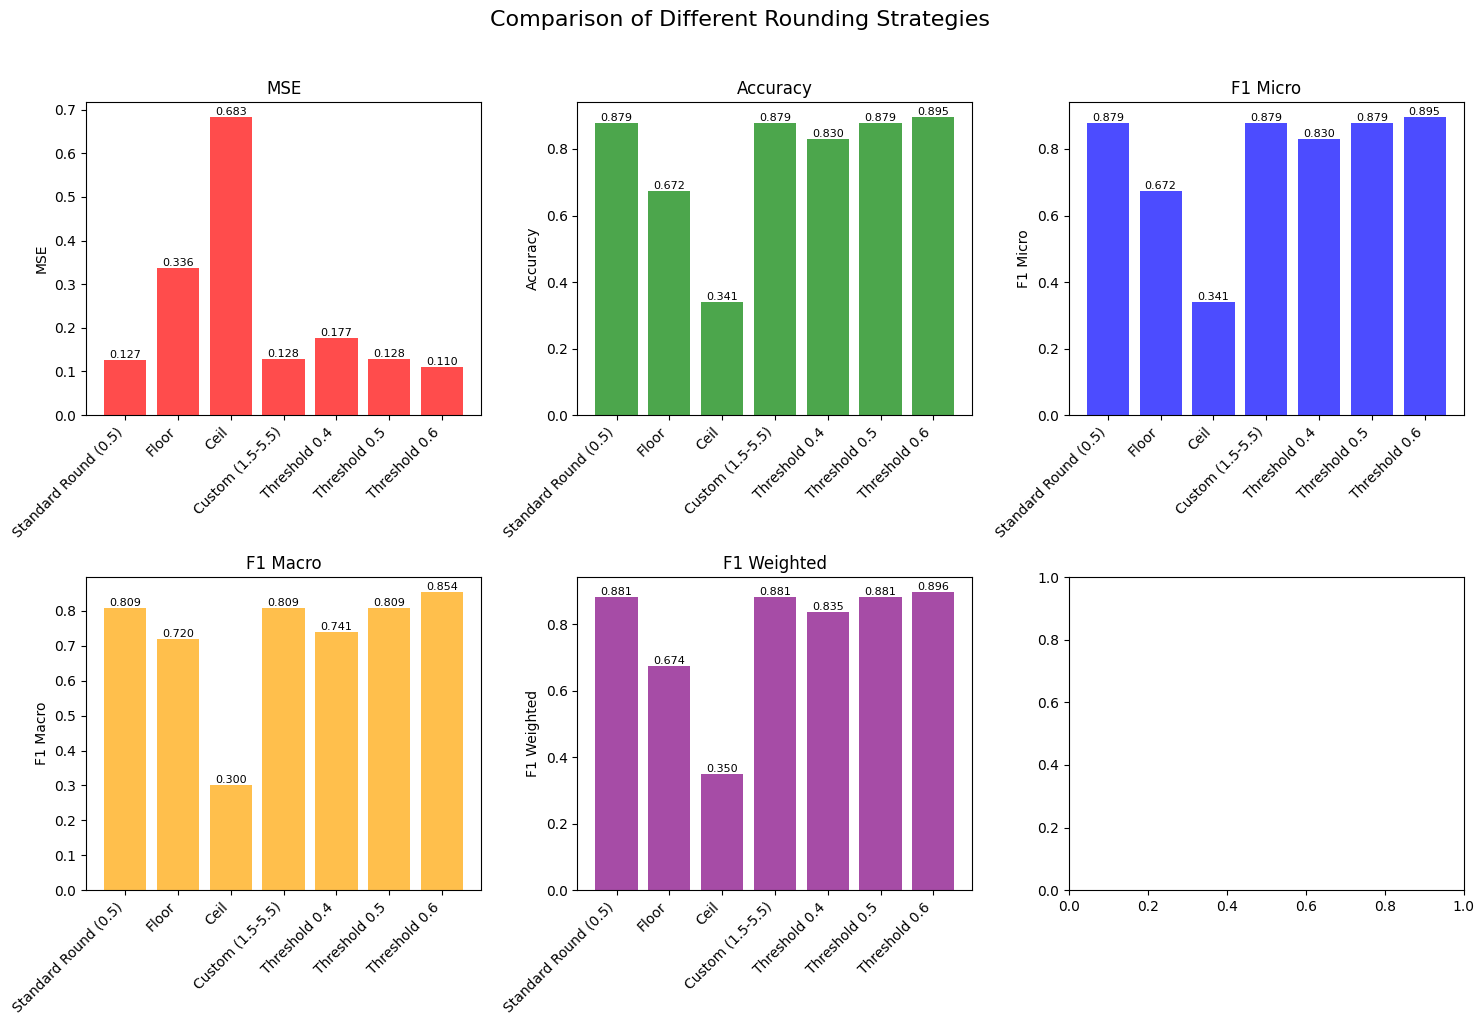

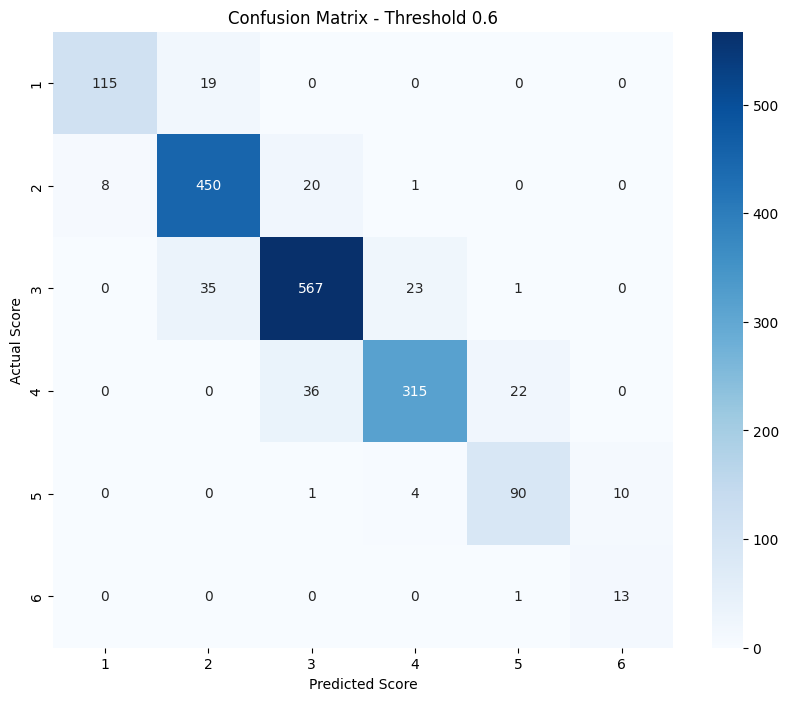


DETAILED CLASSIFICATION REPORT - Threshold 0.6
              precision    recall  f1-score   support

     Score 1       0.93      0.86      0.89       134
     Score 2       0.89      0.94      0.92       479
     Score 3       0.91      0.91      0.91       626
     Score 4       0.92      0.84      0.88       373
     Score 5       0.79      0.86      0.82       105
     Score 6       0.57      0.93      0.70        14

    accuracy                           0.90      1731
   macro avg       0.83      0.89      0.85      1731
weighted avg       0.90      0.90      0.90      1731


EXAMPLE PREDICTIONS WITH BEST STRATEGY

Example 1:
  Raw Prediction: 2.178
  Rounded Prediction: 2
  Actual Score: 2
  Correct: ✅
  Essay preview: you should join the seagoing cowboys program because you will be able to see many sights and you do ...

Example 2:
  Raw Prediction: 5.422
  Rounded Prediction: 5
  Actual Score: 5
  Correct: ✅
  Essay preview: how does the electoral college affect the selecti

In [25]:
import torch
import re
import numpy as np
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import f1_score, mean_squared_error, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import pandas as pd

# Load your saved model and tokenizer
MODEL_PATH = "/content/essay_model_fp16"  # or "./essay_model_quantized"
tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH)

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

# Define the same cleaning function used during training
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    return text

# Custom rounding function
def custom_round(score):
    """
    Custom rounding rules:
    - If score < 1.5: round to 1
    - If 1.5 <= score < 2.5: round to 2
    - If 2.5 <= score < 3.5: round to 3
    - If 3.5 <= score < 4.5: round to 4
    - If 4.5 <= score < 5.5: round to 5
    - If score >= 5.5: round to 6
    """
    if score < 1.5:
        return 1
    elif score < 2.5:
        return 2
    elif score < 3.5:
        return 3
    elif score < 4.5:
        return 4
    elif score < 5.5:
        return 5
    else:
        return 6

# Alternative: More flexible rounding with different thresholds
def custom_round_flexible(score, threshold=0.5):
    """
    Flexible rounding with configurable threshold
    Example: threshold=0.5 means:
    - 1.0 to 1.499... rounds to 1
    - 1.5 to 2.499... rounds to 2
    - etc.
    """
    rounded = round(score)  # Standard rounding
    # If we want more aggressive rounding up at .5
    if score - int(score) >= threshold:
        return min(6, int(score) + 1)
    else:
        return max(1, int(score))

# Test the rounding function
print("="*60)
print("TESTING ROUNDING FUNCTION")
print("="*60)
test_scores = [1.0, 1.2, 1.4, 1.5, 1.6, 2.0, 2.4, 2.5, 3.3, 3.7, 4.0, 4.4, 4.5, 4.6, 5.0, 5.4, 5.5, 5.6, 5.9, 6.0]
for score in test_scores:
    rounded = custom_round(score)
    print(f"Score: {score:.1f} → Rounded: {rounded}")

# Test with different thresholds
print("\n" + "="*60)
print("TESTING DIFFERENT THRESHOLDS")
print("="*60)

thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]
test_score = 5.4  # Example: should this be 5 or 6?

for threshold in thresholds:
    rounded = custom_round_flexible(test_score, threshold)
    print(f"Score {test_score} with threshold {threshold}: {rounded}")

# Function to predict score for an essay
def predict_score(text, max_length=512, stride=256):
    """
    Predict score for an essay, handling long texts by using stride
    """
    # Clean the text
    cleaned_text = clean_text(text)

    # Tokenize with stride
    tokenized = tokenizer(
        cleaned_text,
        truncation=True,
        padding="max_length",
        max_length=max_length,
        return_overflowing_tokens=True,
        stride=stride,
        return_tensors="pt"
    )

    # Move to device
    input_ids = tokenized["input_ids"].to(device)
    attention_mask = tokenized["attention_mask"].to(device)

    # Make predictions for all chunks
    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        scores = outputs.logits.squeeze(-1)

    # Take mean score
    if len(scores.shape) > 0 and scores.shape[0] > 1:
        final_score = scores.mean().item()
    else:
        final_score = scores.item() if len(scores.shape) > 0 else scores.item()

    return final_score

# Now evaluate on your test dataset with different rounding strategies
print("\n" + "="*60)
print("EVALUATING ON TEST DATASET")
print("="*60)

# Load your test dataset (assuming it's still in memory)
# If not, reload it:
from datasets import Dataset
import pandas as pd

# Reload test data
df = pd.read_csv("hf://datasets/tasksource/AES2-essay-scoring/train.csv")
df = df[["full_text", "score"]]
df = df.dropna()

dataset = Dataset.from_pandas(df)
dataset = dataset.train_test_split(test_size=0.1)

# Clean test data
def apply_cleaning_to_example(example):
    example["full_text"] = clean_text(example["full_text"])
    return example

dataset['test'] = dataset['test'].map(apply_cleaning_to_example)

# Get actual scores
actual_scores = dataset['test']['score']

# Predict scores for all test essays
print("Predicting scores for test set...")
predicted_scores_raw = []

for i, text in enumerate(dataset['test']['full_text']):
    if i % 100 == 0:
        print(f"  Processing {i}/{len(dataset['test'])}...")
    score = predict_score(text)
    predicted_scores_raw.append(score)

# Convert to numpy arrays
actual_scores = np.array(actual_scores)
predicted_scores_raw = np.array(predicted_scores_raw)

# Apply different rounding strategies
rounding_strategies = {
    'Standard Round (0.5)': np.round(predicted_scores_raw),
    'Floor': np.floor(predicted_scores_raw),
    'Ceil': np.ceil(predicted_scores_raw),
    'Custom (1.5-5.5)': np.array([custom_round(s) for s in predicted_scores_raw]),
    'Threshold 0.4': np.array([custom_round_flexible(s, 0.4) for s in predicted_scores_raw]),
    'Threshold 0.5': np.array([custom_round_flexible(s, 0.5) for s in predicted_scores_raw]),
    'Threshold 0.6': np.array([custom_round_flexible(s, 0.6) for s in predicted_scores_raw]),
}

# Clip all predictions to 1-6 range
for strategy in rounding_strategies:
    rounding_strategies[strategy] = np.clip(rounding_strategies[strategy], 1, 6)

# Calculate metrics for each strategy
print("\n" + "="*80)
print("RESULTS WITH DIFFERENT ROUNDING STRATEGIES")
print("="*80)

results = []

for strategy, preds in rounding_strategies.items():
    # Calculate metrics
    mse = mean_squared_error(actual_scores, preds)
    f1_micro = f1_score(actual_scores, preds, average='micro')
    f1_macro = f1_score(actual_scores, preds, average='macro')
    f1_weighted = f1_score(actual_scores, preds, average='weighted')
    accuracy = np.mean(preds == actual_scores)

    results.append({
        'Strategy': strategy,
        'MSE': mse,
        'Accuracy': accuracy,
        'F1 Micro': f1_micro,
        'F1 Macro': f1_macro,
        'F1 Weighted': f1_weighted
    })

# Display results
results_df = pd.DataFrame(results)
print("\n" + results_df.to_string(index=False))

# Find the best strategy for each metric
print("\n" + "="*80)
print("BEST STRATEGIES")
print("="*80)
print(f"Best MSE: {results_df.loc[results_df['MSE'].idxmin(), 'Strategy']} - {results_df['MSE'].min():.4f}")
print(f"Best Accuracy: {results_df.loc[results_df['Accuracy'].idxmax(), 'Strategy']} - {results_df['Accuracy'].max():.4f}")
print(f"Best F1 Weighted: {results_df.loc[results_df['F1 Weighted'].idxmax(), 'Strategy']} - {results_df['F1 Weighted'].max():.4f}")

# Visualization
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Plot metrics comparison
metrics = ['MSE', 'Accuracy', 'F1 Micro', 'F1 Macro', 'F1 Weighted']
colors = ['red', 'green', 'blue', 'orange', 'purple']

for i, metric in enumerate(metrics):
    ax = axes[i//3, i%3]
    bars = ax.bar(results_df['Strategy'], results_df[metric], color=colors[i], alpha=0.7)
    ax.set_title(metric)
    ax.set_xticklabels(results_df['Strategy'], rotation=45, ha='right')
    ax.set_ylabel(metric)

    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Comparison of Different Rounding Strategies', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# Confusion Matrix for the best strategy
best_strategy = results_df.loc[results_df['F1 Weighted'].idxmax(), 'Strategy']
best_preds = rounding_strategies[best_strategy]

plt.figure(figsize=(10, 8))
cm = confusion_matrix(actual_scores, best_preds, labels=[1, 2, 3, 4, 5, 6])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[1, 2, 3, 4, 5, 6],
            yticklabels=[1, 2, 3, 4, 5, 6])
plt.title(f'Confusion Matrix - {best_strategy}')
plt.xlabel('Predicted Score')
plt.ylabel('Actual Score')
plt.show()

# Print detailed classification report for best strategy
print("\n" + "="*80)
print(f"DETAILED CLASSIFICATION REPORT - {best_strategy}")
print("="*80)
print(classification_report(actual_scores, best_preds,
                            target_names=['Score 1', 'Score 2', 'Score 3', 'Score 4', 'Score 5', 'Score 6']))

# Show some examples of predictions
print("\n" + "="*80)
print("EXAMPLE PREDICTIONS WITH BEST STRATEGY")
print("="*80)

# Find interesting examples
for i in range(min(10, len(actual_scores))):
    raw_score = predicted_scores_raw[i]
    rounded_score = best_preds[i]
    actual = actual_scores[i]

    print(f"\nExample {i+1}:")
    print(f"  Raw Prediction: {raw_score:.3f}")
    print(f"  Rounded Prediction: {rounded_score}")
    print(f"  Actual Score: {actual}")
    print(f"  Correct: {'✅' if rounded_score == actual else '❌'}")
    print(f"  Essay preview: {dataset['test'][i]['full_text'][:100]}...")

# Optional: Test with specific example to see rounding
print("\n" + "="*80)
print("TESTING SPECIFIC ROUNDING EXAMPLES")
print("="*80)

test_examples = [
    ("Score near 5.5 boundary", "This essay should be around 5.5. " * 50),
    ("Score near 1.5 boundary", "This essay is very short and basic. " * 10),
    ("Score near 4.5 boundary", "This essay is quite good overall. " * 40),
]

for name, essay in test_examples:
    raw_score = predict_score(essay)
    rounded_score = custom_round(raw_score)
    print(f"\n{name}:")
    print(f"  Raw Score: {raw_score:.4f}")
    print(f"  Rounded Score: {rounded_score}")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

TESTING ROUNDING FUNCTION
Score: 1.0 → Rounded: 1
Score: 1.2 → Rounded: 1
Score: 1.4 → Rounded: 1
Score: 1.5 → Rounded: 2
Score: 1.6 → Rounded: 2
Score: 2.0 → Rounded: 2
Score: 2.4 → Rounded: 2
Score: 2.5 → Rounded: 3
Score: 3.3 → Rounded: 3
Score: 3.7 → Rounded: 4
Score: 4.0 → Rounded: 4
Score: 4.4 → Rounded: 4
Score: 4.5 → Rounded: 5
Score: 4.6 → Rounded: 5
Score: 5.0 → Rounded: 5
Score: 5.4 → Rounded: 5
Score: 5.5 → Rounded: 6
Score: 5.6 → Rounded: 6
Score: 5.9 → Rounded: 6
Score: 6.0 → Rounded: 6

TESTING DIFFERENT THRESHOLDS
Score 5.4 with threshold 0.3: 6
Score 5.4 with threshold 0.4: 6
Score 5.4 with threshold 0.5: 5
Score 5.4 with threshold 0.6: 5
Score 5.4 with threshold 0.7: 5

EVALUATING ON TEST DATASET


Map:   0%|          | 0/1731 [00:00<?, ? examples/s]

Predicting scores for test set...
  Processing 0/1731...
  Processing 100/1731...
  Processing 200/1731...
  Processing 300/1731...
  Processing 400/1731...
  Processing 500/1731...
  Processing 600/1731...
  Processing 700/1731...
  Processing 800/1731...
  Processing 900/1731...
  Processing 1000/1731...
  Processing 1100/1731...
  Processing 1200/1731...
  Processing 1300/1731...
  Processing 1400/1731...
  Processing 1500/1731...
  Processing 1600/1731...
  Processing 1700/1731...

RESULTS WITH DIFFERENT ROUNDING STRATEGIES

            Strategy      MSE  Accuracy  F1 Micro  F1 Macro  F1 Weighted
Standard Round (0.5) 0.143270  0.865396  0.865396  0.799060     0.867913
               Floor 0.358174  0.657423  0.657423  0.722014     0.661531
                Ceil 0.688619  0.343732  0.343732  0.289641     0.351973
    Custom (1.5-5.5) 0.143270  0.865396  0.865396  0.799060     0.867913
       Threshold 0.4 0.195841  0.814558  0.814558  0.725655     0.819581
       Threshold 0.5 0.1432

/tmp/ipykernel_700/2306505837.py:228: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(results_df['Strategy'], rotation=45, ha='right')
/tmp/ipykernel_700/2306505837.py:228: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(results_df['Strategy'], rotation=45, ha='right')
/tmp/ipykernel_700/2306505837.py:228: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(results_df['Strategy'], rotation=45, ha='right')
/tmp/ipykernel_700/2306505837.py:228: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(results_df['Strategy'], rotation=45, ha='right')
/tmp/ipykernel_700/2306505837.py:228: UserWarning: set_t

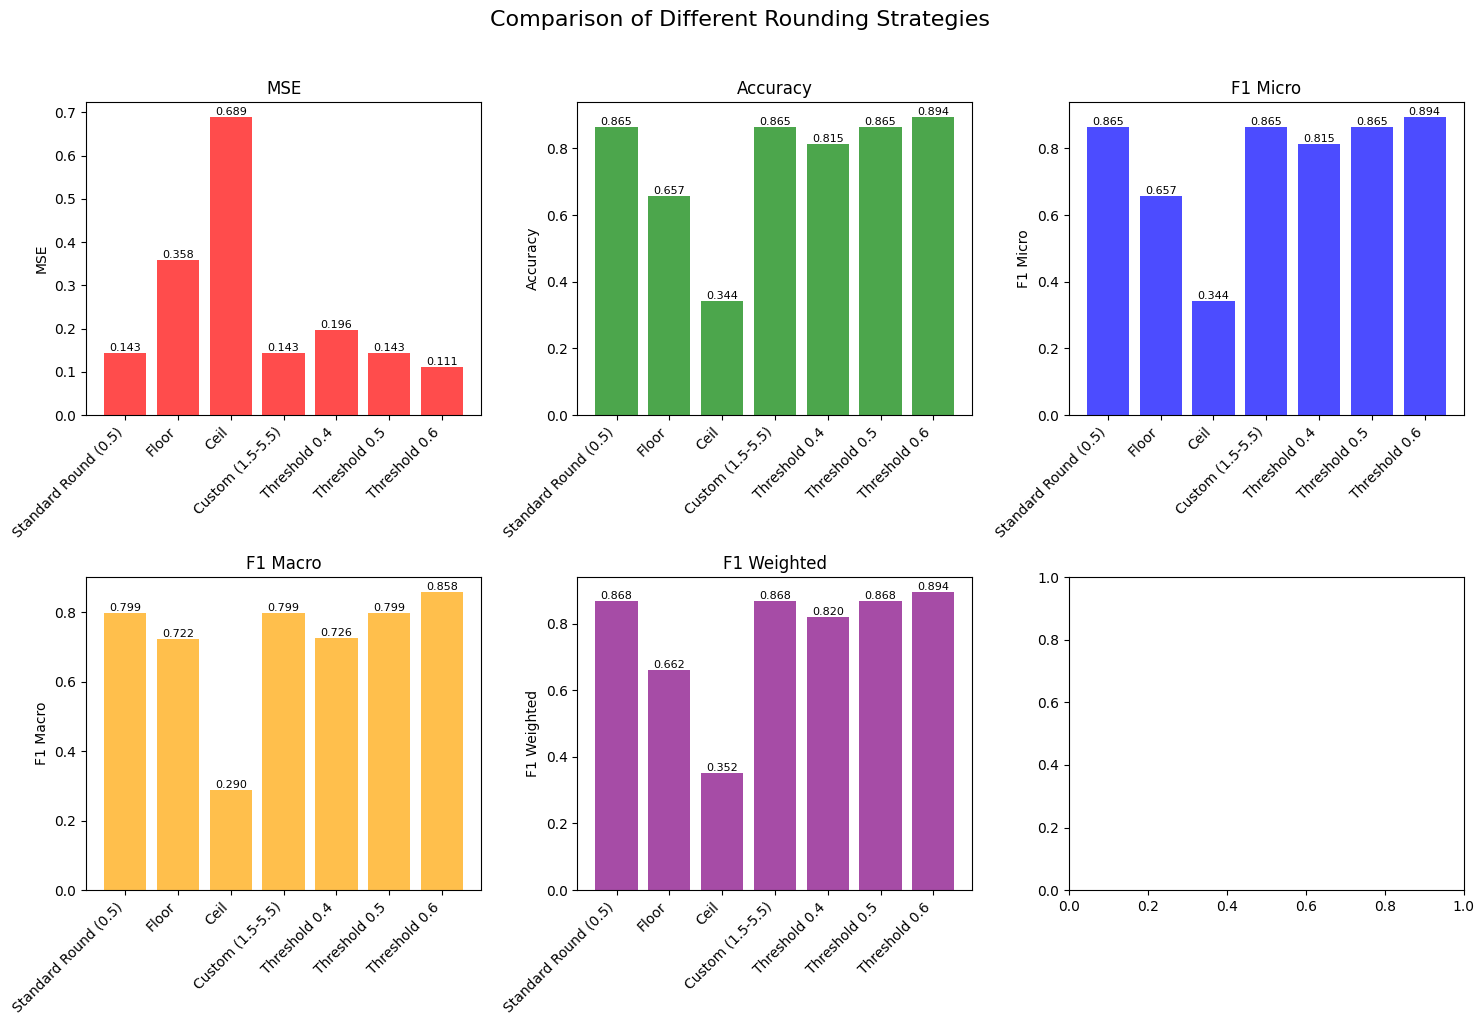

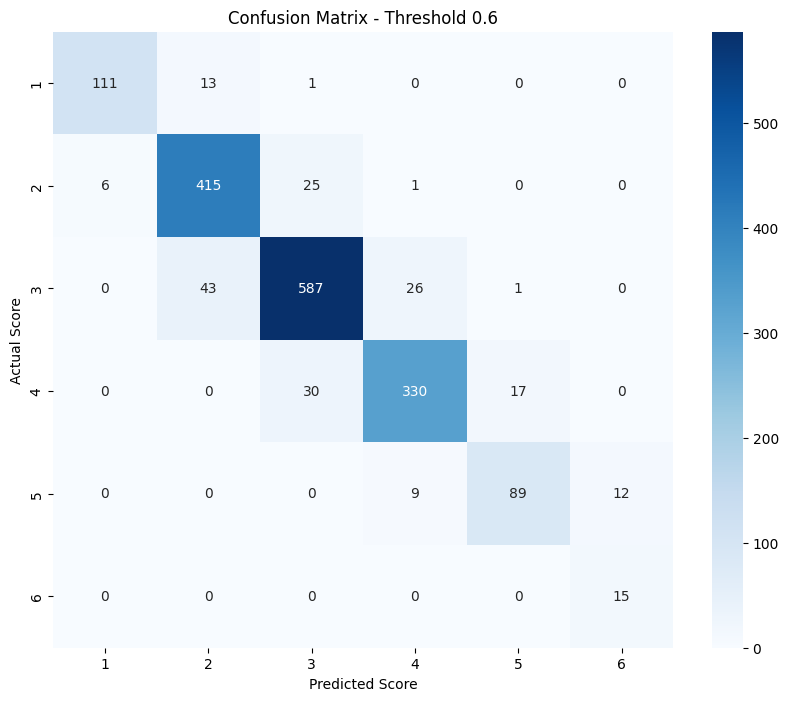


DETAILED CLASSIFICATION REPORT - Threshold 0.6
              precision    recall  f1-score   support

     Score 1       0.95      0.89      0.92       125
     Score 2       0.88      0.93      0.90       447
     Score 3       0.91      0.89      0.90       657
     Score 4       0.90      0.88      0.89       377
     Score 5       0.83      0.81      0.82       110
     Score 6       0.56      1.00      0.71        15

    accuracy                           0.89      1731
   macro avg       0.84      0.90      0.86      1731
weighted avg       0.90      0.89      0.89      1731


EXAMPLE PREDICTIONS WITH BEST STRATEGY

Example 1:
  Raw Prediction: 1.944
  Rounded Prediction: 2
  Actual Score: 2
  Correct: ✅
  Essay preview: in the challenge of exploring venus the author suggests that studying venus is a worthy pursuit desp...

Example 2:
  Raw Prediction: 1.965
  Rounded Prediction: 2
  Actual Score: 2
  Correct: ✅
  Essay preview: i would argue in favor of changing to election by

In [26]:
import torch
import re
import numpy as np
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import f1_score, mean_squared_error, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import pandas as pd

# Load your saved model and tokenizer
MODEL_PATH = "/content/essay_model_manual"  # or "./essay_model_quantized"
tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH)

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

# Define the same cleaning function used during training
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    return text

# Custom rounding function
def custom_round(score):
    """
    Custom rounding rules:
    - If score < 1.5: round to 1
    - If 1.5 <= score < 2.5: round to 2
    - If 2.5 <= score < 3.5: round to 3
    - If 3.5 <= score < 4.5: round to 4
    - If 4.5 <= score < 5.5: round to 5
    - If score >= 5.5: round to 6
    """
    if score < 1.5:
        return 1
    elif score < 2.5:
        return 2
    elif score < 3.5:
        return 3
    elif score < 4.5:
        return 4
    elif score < 5.5:
        return 5
    else:
        return 6

# Alternative: More flexible rounding with different thresholds
def custom_round_flexible(score, threshold=0.5):
    """
    Flexible rounding with configurable threshold
    Example: threshold=0.5 means:
    - 1.0 to 1.499... rounds to 1
    - 1.5 to 2.499... rounds to 2
    - etc.
    """
    rounded = round(score)  # Standard rounding
    # If we want more aggressive rounding up at .5
    if score - int(score) >= threshold:
        return min(6, int(score) + 1)
    else:
        return max(1, int(score))

# Test the rounding function
print("="*60)
print("TESTING ROUNDING FUNCTION")
print("="*60)
test_scores = [1.0, 1.2, 1.4, 1.5, 1.6, 2.0, 2.4, 2.5, 3.3, 3.7, 4.0, 4.4, 4.5, 4.6, 5.0, 5.4, 5.5, 5.6, 5.9, 6.0]
for score in test_scores:
    rounded = custom_round(score)
    print(f"Score: {score:.1f} → Rounded: {rounded}")

# Test with different thresholds
print("\n" + "="*60)
print("TESTING DIFFERENT THRESHOLDS")
print("="*60)

thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]
test_score = 5.4  # Example: should this be 5 or 6?

for threshold in thresholds:
    rounded = custom_round_flexible(test_score, threshold)
    print(f"Score {test_score} with threshold {threshold}: {rounded}")

# Function to predict score for an essay
def predict_score(text, max_length=512, stride=256):
    """
    Predict score for an essay, handling long texts by using stride
    """
    # Clean the text
    cleaned_text = clean_text(text)

    # Tokenize with stride
    tokenized = tokenizer(
        cleaned_text,
        truncation=True,
        padding="max_length",
        max_length=max_length,
        return_overflowing_tokens=True,
        stride=stride,
        return_tensors="pt"
    )

    # Move to device
    input_ids = tokenized["input_ids"].to(device)
    attention_mask = tokenized["attention_mask"].to(device)

    # Make predictions for all chunks
    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        scores = outputs.logits.squeeze(-1)

    # Take mean score
    if len(scores.shape) > 0 and scores.shape[0] > 1:
        final_score = scores.mean().item()
    else:
        final_score = scores.item() if len(scores.shape) > 0 else scores.item()

    return final_score

# Now evaluate on your test dataset with different rounding strategies
print("\n" + "="*60)
print("EVALUATING ON TEST DATASET")
print("="*60)

# Load your test dataset (assuming it's still in memory)
# If not, reload it:
from datasets import Dataset
import pandas as pd

# Reload test data
df = pd.read_csv("hf://datasets/tasksource/AES2-essay-scoring/train.csv")
df = df[["full_text", "score"]]
df = df.dropna()

dataset = Dataset.from_pandas(df)
dataset = dataset.train_test_split(test_size=0.1)

# Clean test data
def apply_cleaning_to_example(example):
    example["full_text"] = clean_text(example["full_text"])
    return example

dataset['test'] = dataset['test'].map(apply_cleaning_to_example)

# Get actual scores
actual_scores = dataset['test']['score']

# Predict scores for all test essays
print("Predicting scores for test set...")
predicted_scores_raw = []

for i, text in enumerate(dataset['test']['full_text']):
    if i % 100 == 0:
        print(f"  Processing {i}/{len(dataset['test'])}...")
    score = predict_score(text)
    predicted_scores_raw.append(score)

# Convert to numpy arrays
actual_scores = np.array(actual_scores)
predicted_scores_raw = np.array(predicted_scores_raw)

# Apply different rounding strategies
rounding_strategies = {
    'Standard Round (0.5)': np.round(predicted_scores_raw),
    'Floor': np.floor(predicted_scores_raw),
    'Ceil': np.ceil(predicted_scores_raw),
    'Custom (1.5-5.5)': np.array([custom_round(s) for s in predicted_scores_raw]),
    'Threshold 0.4': np.array([custom_round_flexible(s, 0.4) for s in predicted_scores_raw]),
    'Threshold 0.5': np.array([custom_round_flexible(s, 0.5) for s in predicted_scores_raw]),
    'Threshold 0.6': np.array([custom_round_flexible(s, 0.6) for s in predicted_scores_raw]),
}

# Clip all predictions to 1-6 range
for strategy in rounding_strategies:
    rounding_strategies[strategy] = np.clip(rounding_strategies[strategy], 1, 6)

# Calculate metrics for each strategy
print("\n" + "="*80)
print("RESULTS WITH DIFFERENT ROUNDING STRATEGIES")
print("="*80)

results = []

for strategy, preds in rounding_strategies.items():
    # Calculate metrics
    mse = mean_squared_error(actual_scores, preds)
    f1_micro = f1_score(actual_scores, preds, average='micro')
    f1_macro = f1_score(actual_scores, preds, average='macro')
    f1_weighted = f1_score(actual_scores, preds, average='weighted')
    accuracy = np.mean(preds == actual_scores)

    results.append({
        'Strategy': strategy,
        'MSE': mse,
        'Accuracy': accuracy,
        'F1 Micro': f1_micro,
        'F1 Macro': f1_macro,
        'F1 Weighted': f1_weighted
    })

# Display results
results_df = pd.DataFrame(results)
print("\n" + results_df.to_string(index=False))

# Find the best strategy for each metric
print("\n" + "="*80)
print("BEST STRATEGIES")
print("="*80)
print(f"Best MSE: {results_df.loc[results_df['MSE'].idxmin(), 'Strategy']} - {results_df['MSE'].min():.4f}")
print(f"Best Accuracy: {results_df.loc[results_df['Accuracy'].idxmax(), 'Strategy']} - {results_df['Accuracy'].max():.4f}")
print(f"Best F1 Weighted: {results_df.loc[results_df['F1 Weighted'].idxmax(), 'Strategy']} - {results_df['F1 Weighted'].max():.4f}")

# Visualization
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Plot metrics comparison
metrics = ['MSE', 'Accuracy', 'F1 Micro', 'F1 Macro', 'F1 Weighted']
colors = ['red', 'green', 'blue', 'orange', 'purple']

for i, metric in enumerate(metrics):
    ax = axes[i//3, i%3]
    bars = ax.bar(results_df['Strategy'], results_df[metric], color=colors[i], alpha=0.7)
    ax.set_title(metric)
    ax.set_xticklabels(results_df['Strategy'], rotation=45, ha='right')
    ax.set_ylabel(metric)

    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Comparison of Different Rounding Strategies', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# Confusion Matrix for the best strategy
best_strategy = results_df.loc[results_df['F1 Weighted'].idxmax(), 'Strategy']
best_preds = rounding_strategies[best_strategy]

plt.figure(figsize=(10, 8))
cm = confusion_matrix(actual_scores, best_preds, labels=[1, 2, 3, 4, 5, 6])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[1, 2, 3, 4, 5, 6],
            yticklabels=[1, 2, 3, 4, 5, 6])
plt.title(f'Confusion Matrix - {best_strategy}')
plt.xlabel('Predicted Score')
plt.ylabel('Actual Score')
plt.show()

# Print detailed classification report for best strategy
print("\n" + "="*80)
print(f"DETAILED CLASSIFICATION REPORT - {best_strategy}")
print("="*80)
print(classification_report(actual_scores, best_preds,
                            target_names=['Score 1', 'Score 2', 'Score 3', 'Score 4', 'Score 5', 'Score 6']))

# Show some examples of predictions
print("\n" + "="*80)
print("EXAMPLE PREDICTIONS WITH BEST STRATEGY")
print("="*80)

# Find interesting examples
for i in range(min(10, len(actual_scores))):
    raw_score = predicted_scores_raw[i]
    rounded_score = best_preds[i]
    actual = actual_scores[i]

    print(f"\nExample {i+1}:")
    print(f"  Raw Prediction: {raw_score:.3f}")
    print(f"  Rounded Prediction: {rounded_score}")
    print(f"  Actual Score: {actual}")
    print(f"  Correct: {'✅' if rounded_score == actual else '❌'}")
    print(f"  Essay preview: {dataset['test'][i]['full_text'][:100]}...")

# Optional: Test with specific example to see rounding
print("\n" + "="*80)
print("TESTING SPECIFIC ROUNDING EXAMPLES")
print("="*80)

test_examples = [
    ("Score near 5.5 boundary", "This essay should be around 5.5. " * 50),
    ("Score near 1.5 boundary", "This essay is very short and basic. " * 10),
    ("Score near 4.5 boundary", "This essay is quite good overall. " * 40),
]

for name, essay in test_examples:
    raw_score = predict_score(essay)
    rounded_score = custom_round(raw_score)
    print(f"\n{name}:")
    print(f"  Raw Score: {raw_score:.4f}")
    print(f"  Rounded Score: {rounded_score}")